# 01. ベクトルと行列の幾何 — 空間を変形するルール

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 10. Exercises |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

この章では、線形代数の主役 2 人に会います。

- **ベクトル** — 「量」と「方向」をまとめてひとつの対象として扱うもの
- **行列** — 空間全体を一斉に変形するルール

ポイントはただひとつ。
**行列とは、ベクトルを入れると別のベクトルが出てくる「変換装置」であり、
その正体は「基底ベクトルの行き先表」である**、ということです。
これが腑に落ちると、行列積の定義も行列式も、すべて自然に見えてきます。

## 2. Problem — 出発点となる問題

次の 3 つの問題は、見かけは違いますが同じ構造を持っています。

**問題 A(移動)** 東に 3 km、北に 2 km 移動した。さらに東に 1 km、南に 4 km 移動した。
結局、出発点からどこにいるか?

**問題 B(力の合成)** 物体に 2 つの力が同時にかかっている。合計の力はどちら向きにどの強さか?

**問題 C(画面の回転)** ゲーム画面上の何千個の点を、一斉に 30° 回転させたい。
点ごとに三角関数を考え直すのではなく、「回転」という操作そのものを 1 個のデータで表せないか?

A と B は「向きと大きさを持つ量の足し算」、C は「空間全体の変形の記述」の問題です。
前者に答えるのが **ベクトル**、後者に答えるのが **行列** です。

## 3. Intuition — ベクトルの2つの顔

ベクトルには 2 つの見方があり、どちらも正しく、行き来できることが大事です。

1. **幾何の顔**: 原点から伸びる矢印。向きと長さを持つ。
2. **データの顔**: 数を縦に並べたリスト。$(3, 2)$ は「東に 3、北に 2」の省略形。

機械学習で「ユーザーを 100 次元ベクトルで表す」と言うときはデータの顔ですが、
「似たユーザーはベクトルの向きが近い」と言った瞬間に幾何の顔に切り替わっています。
この往復こそが線形代数の使い方です。

In [1]:
# Shared setup for this notebook.
import numpy as np
import matplotlib.pyplot as plt

from la_book import plotting

np.set_printoptions(precision=3, suppress=True)

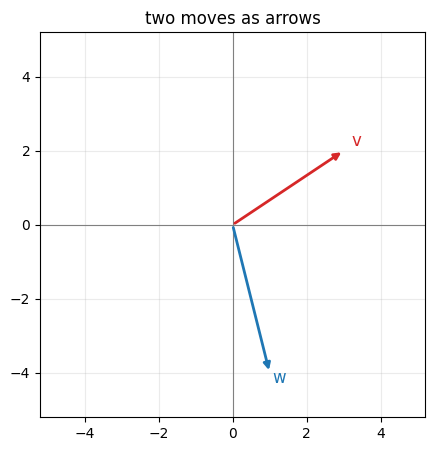

v = [3. 2.]  w = [ 1. -4.]


In [2]:
# A vector is both an arrow and a list of numbers.
v = np.array([3.0, 2.0])   # problem A: first move
w = np.array([1.0, -4.0])  # problem A: second move

plotting.plot_vectors([v, w], labels=["v", "w"])
plt.title("two moves as arrows")
plt.show()
print("v =", v, " w =", w)

## 4. Visualization — 足し算とスカラー倍

ベクトルの演算は 2 つだけです。

- **足し算**: 矢印をつなげる(平行四辺形の対角線)
- **スカラー倍**: 向きを変えずに伸び縮みさせる(負の数なら逆向き)

「移動を続けて行う」ことが足し算に、「同じ向きに 2 倍進む」ことがスカラー倍に対応します。

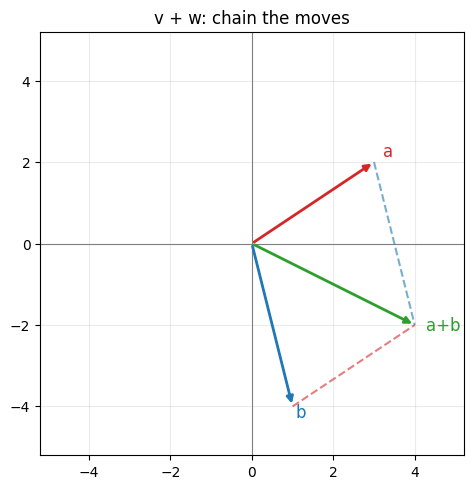

v + w = [ 4. -2.]


In [3]:
# Vector addition: the parallelogram picture. v + w answers problem A.
plotting.plot_vector_sum(v, w)
plt.title("v + w: chain the moves")
plt.show()
print("v + w =", v + w)

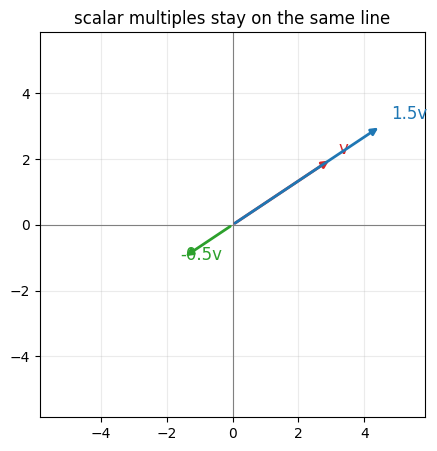

In [4]:
# Scalar multiplication: stretch, shrink, or flip a vector.
plotting.plot_vectors(
    [v, 1.5 * v, -0.5 * v],
    labels=["v", "1.5v", "-0.5v"],
)
plt.title("scalar multiples stay on the same line")
plt.show()

足し算とスカラー倍を組み合わせたものを **線形結合** と呼びます。

$$
c_1 v_1 + c_2 v_2 + \cdots + c_k v_k
$$

「手持ちのベクトルを混ぜ合わせて作れるベクトル全体」が線形結合の世界です。
実は 2 本のベクトル $(1,0)$ と $(0,1)$ の線形結合だけで、平面上のすべての点が作れます。
この 2 本を **標準基底** と呼び、$e_1, e_2$ と書きます。

## 5. Definition — ベクトル・行列・行列積

ここまでの直感を数式にします。

**ベクトル**: 実数を $n$ 個並べたもの。$\mathbb{R}^n$ の要素。

$$
v = \begin{pmatrix} v_1 \\ \vdots \\ v_n \end{pmatrix}, \qquad
v + w = \begin{pmatrix} v_1 + w_1 \\ \vdots \\ v_n + w_n \end{pmatrix}, \qquad
c\,v = \begin{pmatrix} c v_1 \\ \vdots \\ c v_n \end{pmatrix}
$$

**行列**: 数を $m$ 行 $n$ 列に並べた表 $A \in \mathbb{R}^{m \times n}$。

**行列とベクトルの積**: これが核心です。$A$ の列を $a_1, \dots, a_n$ とすると

$$
A x = x_1 a_1 + x_2 a_2 + \cdots + x_n a_n
$$

つまり **$Ax$ とは「$A$ の列ベクトルを、$x$ の成分を配合比として混ぜたもの」** です。
特に $A e_1 = a_1$(第 1 列)、$A e_2 = a_2$(第 2 列)。
**行列の各列は「基底ベクトルの行き先」** にほかなりません。

**行列同士の積**: 変換を続けて行うことに対応させて定義します。

$$
(AB)x = A(Bx)
$$

成分で書くと $(AB)_{ij} = \sum_k A_{ik} B_{kj}$ という「行×列」の計算規則になりますが、
これは「先に $B$ で変形し、続けて $A$ で変形する」を実現するための必然的な定義です。

## 6. Computation — NumPy で計算する

NumPy では `@` が行列積(数学の積)、`*` は成分ごとの積です。混同が事故のもとなので注意。

In [5]:
# Matrix-vector product: Ax mixes the columns of A with weights x.
A = np.array([[2.0, 1.0],
              [0.0, 3.0]])
x = np.array([2.0, 1.0])

a1, a2 = A[:, 0], A[:, 1]
print("A @ x          =", A @ x)
print("x1*a1 + x2*a2  =", x[0] * a1 + x[1] * a2)  # same thing
print()
print("A * x (elementwise, NOT the matrix product):")
print(A * x)

A @ x          = [5. 3.]
x1*a1 + x2*a2  = [5. 3.]

A * x (elementwise, NOT the matrix product):
[[4. 1.]
 [0. 3.]]


In [6]:
# The columns of A are the destinations of the basis vectors.
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])
print("A @ e1 =", A @ e1, "= 1st column of A")
print("A @ e2 =", A @ e2, "= 2nd column of A")

A @ e1 = [2. 0.] = 1st column of A
A @ e2 = [1. 3.] = 2nd column of A


### 行列は空間全体を変形する

$Ax$ を「1 本のベクトルの変換」と見るだけでなく、
**平面上のすべての点に一斉に適用した結果** を見ると、行列の個性が現れます。
等間隔のグリッドがどう歪むかを見るのが一番です。

- グリッド線は曲がらず、直線のまま(これが「線形」の意味)
- 平行だった線は平行のまま
- 原点は動かない

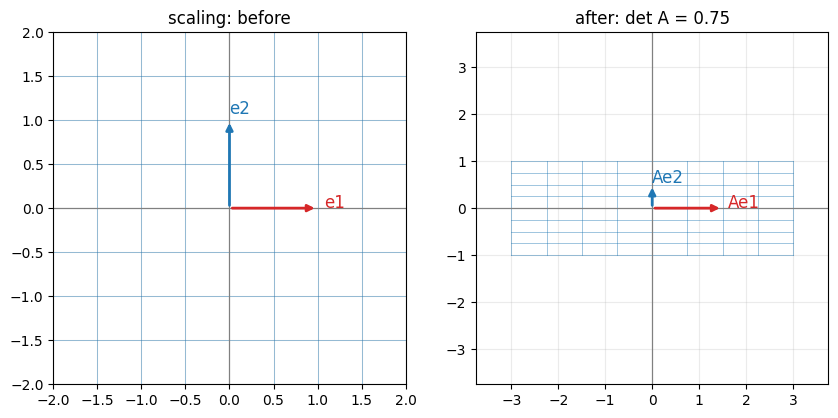

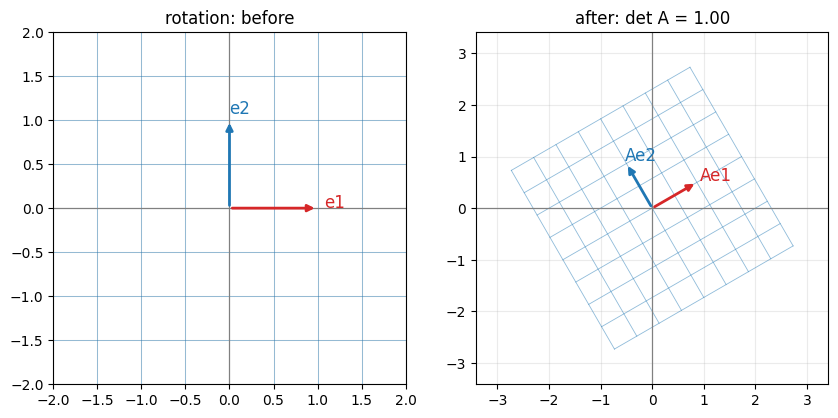

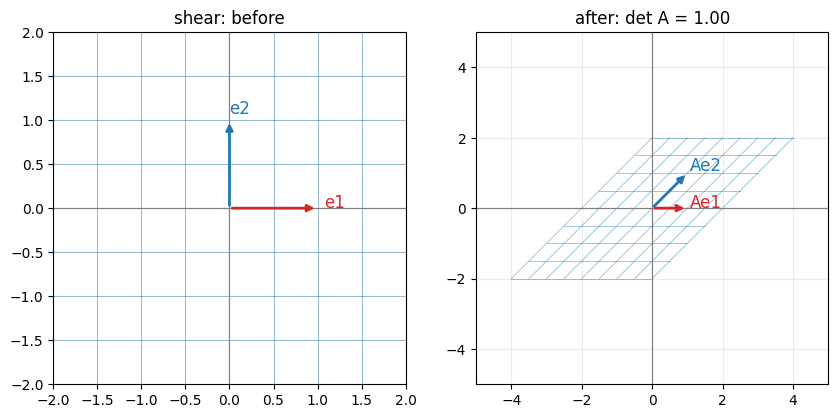

In [7]:
# Typical 2x2 transformations seen as grid deformations.
transforms = {
    "scaling":  np.array([[1.5, 0.0], [0.0, 0.5]]),
    "rotation": np.array([[np.cos(np.pi / 6), -np.sin(np.pi / 6)],
                          [np.sin(np.pi / 6),  np.cos(np.pi / 6)]]),
    "shear":    np.array([[1.0, 1.0], [0.0, 1.0]]),
}
for name, M in transforms.items():
    axes = plotting.plot_grid_transform(M)
    axes[0].set_title(f"{name}: before")
    plt.show()

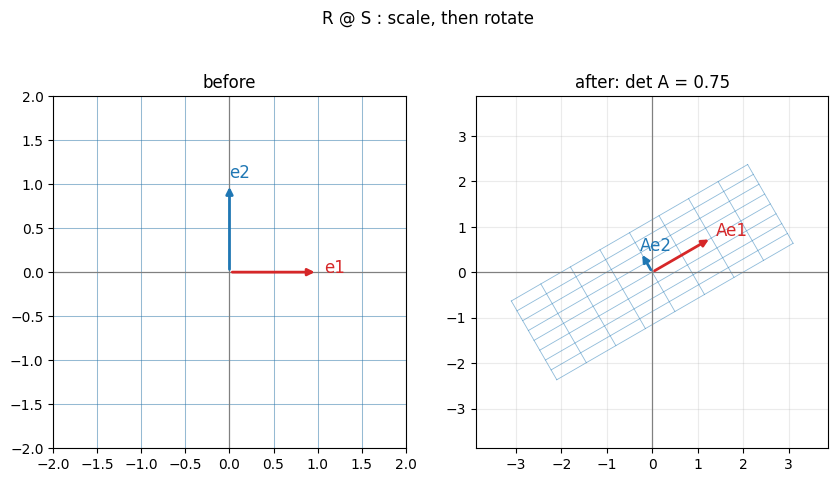

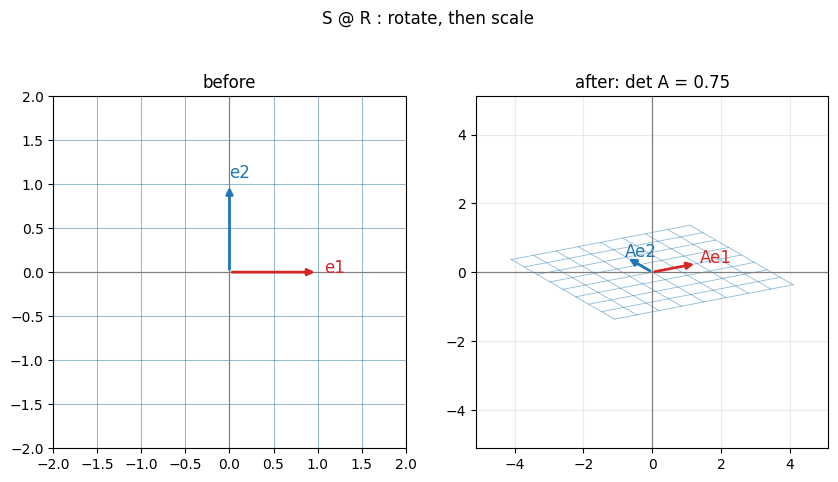

In [8]:
# Composition = matrix product. Order matters!
R = transforms["rotation"]
S = transforms["scaling"]

plotting.plot_grid_transform(R @ S)  # scale first, then rotate
plt.suptitle("R @ S : scale, then rotate", y=1.02)
plt.show()

plotting.plot_grid_transform(S @ R)  # rotate first, then scale
plt.suptitle("S @ R : rotate, then scale", y=1.02)
plt.show()

### インタラクティブに触ってみる(JupyterLab のみ)

下のセルは、2×2 行列の 4 成分をスライダーで動かしてグリッド変形を観察する
ipywidgets デモです。静的 HTML では動かないので、上の静的な図で同じ内容を確認してください。
`b`(右上)を動かすと「せん断」、対角だけ動かすと「拡大縮小」が見えます。

In [9]:
# Interactive (JupyterLab only): drag sliders for the matrix entries.
from la_book.widgets import interactive_transform

interactive_transform()

interactive(children=(FloatSlider(value=1.0, description='a', max=2.0, min=-2.0), FloatSlider(value=0.0, descr…

<function la_book.widgets.interactive_transform.<locals>.draw(a, b, c, d)>

こちらは **静的 HTML でも動く** Plotly 版です(スライダーで代表的な変換を切り替え)。

In [10]:
# Plotly slider over named transforms (works in the exported HTML too).
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"
mats = [
    ("identity", np.eye(2)),
    ("scale", np.array([[1.5, 0.0], [0.0, 0.5]])),
    ("rotate 30", transforms["rotation"]),
    ("shear", np.array([[1.0, 1.0], [0.0, 1.0]])),
    ("degenerate", np.array([[1.0, 2.0], [0.5, 1.0]])),
]
fig = plotting.plotly_grid_transform([M for _, M in mats], [n for n, _ in mats],
                                     title="how each matrix deforms the grid")
fig.show()

## 7. Invariant — 何が保存されるか

行列による変換(線形写像)では、どんな行列でも必ず:

- **原点は原点のまま**: $A\,0 = 0$
- **直線は直線のまま**(または 1 点につぶれる)
- **平行は平行のまま**
- **線形結合の関係が保存される**: $A(c_1 u + c_2 v) = c_1 Au + c_2 Av$

最後の式が **線形性** であり、線形代数全体を支える性質です。
「足してから変換しても、変換してから足しても同じ」。
だから、基底ベクトルの行き先(= 行列の列)さえ知れば、すべての点の行き先が決まるのです。

In [11]:
# Linearity check: A(c1*u + c2*v) == c1*Au + c2*Av.
rng = np.random.default_rng(0)
u, v_ = rng.standard_normal(2), rng.standard_normal(2)
c1, c2 = 2.0, -3.0

lhs = A @ (c1 * u + c2 * v_)
rhs = c1 * (A @ u) + c2 * (A @ v_)
print("A(c1 u + c2 v) =", lhs)
print("c1 Au + c2 Av  =", rhs)
print("equal:", np.allclose(lhs, rhs))

A(c1 u + c2 v) = [-3.919 -1.737]
c1 Au + c2 Av  = [-3.919 -1.737]
equal: True


## 8. Failure Mode — 何が壊れると問題か

**(1) 積の順序を勝手に入れ替える。** 行列積は一般に $AB \neq BA$ です。
「回してから伸ばす」と「伸ばしてから回す」は別の変換でした(上の図)。

In [12]:
# Non-commutativity: AB != BA in general.
print("R @ S =\n", R @ S)
print("S @ R =\n", S @ R)
print("equal:", np.allclose(R @ S, S @ R))

R @ S =
 [[ 1.299 -0.25 ]
 [ 0.75   0.433]]
S @ R =
 [[ 1.299 -0.75 ]
 [ 0.25   0.433]]
equal: False


**(2) 形(次元)が合っていない積。** $(m \times n)$ 行列は $n$ 次元ベクトルにしか掛けられません。
NumPy はエラーを出してくれますが、ブロードキャストが「親切に」動いてしまい
気づかないケースもあります(`*` と `@` の混同が典型)。

**(3) 空間がつぶれる行列。** 列ベクトルが同一直線上にあると、平面全体が 1 本の直線につぶれます。
つぶれた情報は元に戻せません(逆行列が存在しない)。これは 02 章「ランク」の主役です。

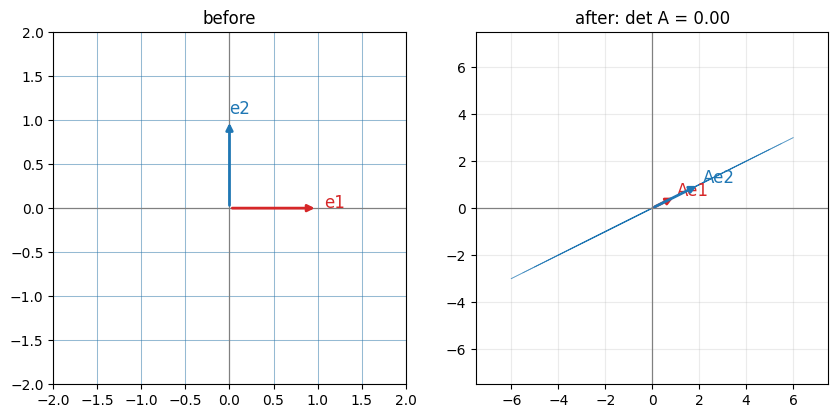

In [13]:
# A degenerate matrix: both columns lie on the same line -> the plane collapses.
D = np.array([[1.0, 2.0],
              [0.5, 1.0]])  # second column = 2 * first column
plotting.plot_grid_transform(D)
plt.show()

### 行列式の直感的導入 — 面積の倍率

上の「つぶれ」を 1 個の数で検出できます。
単位正方形(面積 1)が、変換後にどれだけの面積になるかを測ればよい。
この **面積の倍率** が **行列式** $\det A$ です。

$$
\det \begin{pmatrix} a & b \\ c & d \end{pmatrix} = ad - bc
$$

- $|\det A| = $ 面積が何倍になるか
- $\det A < 0$ は「裏返し」(向きの反転)が起きたことを意味する
- $\det A = 0$ は「面積が 0 につぶれた」= 空間の次元が落ちた、の合図

きちんとした性質は 03 章で扱います。ここでは「面積倍率」という絵だけ持ち帰ってください。

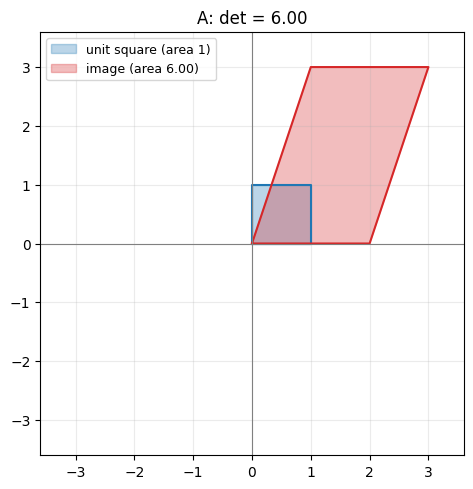

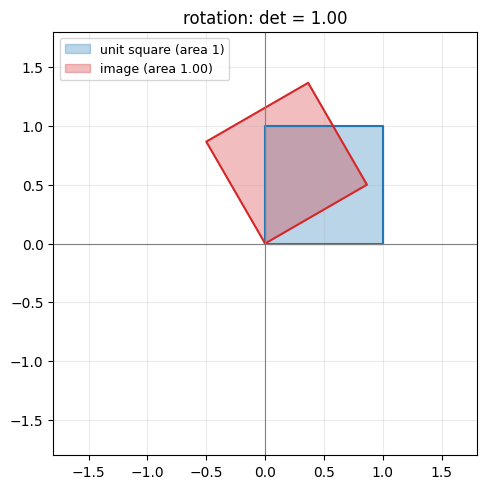

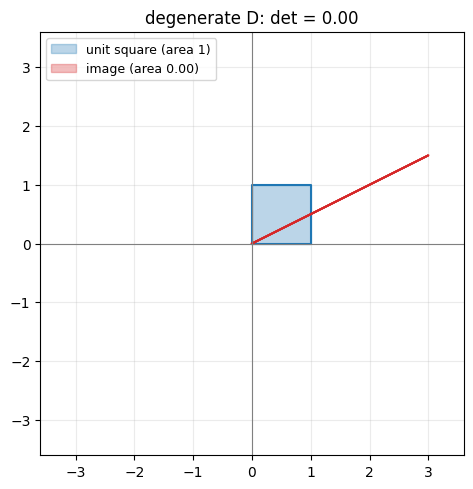

In [14]:
# The determinant is the area scaling factor of the unit square.
for M, name in [(A, "A"), (R, "rotation"), (D, "degenerate D")]:
    plotting.plot_unit_square(M)
    plt.title(f"{name}: det = {np.linalg.det(M):.2f}")
    plt.show()

## 9. Application — どこで使われるか

**CG・ゲーム**: 何万頂点のモデルの回転・拡大も、行列 1 個を全頂点に掛けるだけ。
GPU はまさにこの行列×ベクトル積を大量並列で行う装置です。

**データ分析**: $m$ 人 × $n$ 項目のデータ表はそのまま $m \times n$ 行列。
「行列に何を掛けるか」がそのまま「データをどう加工するか」になります。

ミニ例として、多角形(点の集まり)を一括変換してみます。

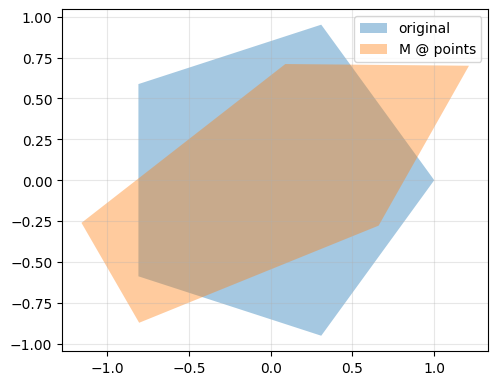

In [15]:
# Transform a whole polygon (many points) with a single matrix multiply.
theta = np.linspace(0, 2 * np.pi, 6)[:-1]
star = np.vstack([np.cos(theta), np.sin(theta)])  # 2 x 5 points
M = transforms["rotation"] @ np.array([[1.4, 0.0], [0.0, 0.6]])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.fill(star[0], star[1], alpha=0.4, label="original")
out = M @ star
ax.fill(out[0], out[1], alpha=0.4, label="M @ points")
ax.legend()
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.show()

## 10. Exercises

1. $v = (2, 1)$, $w = (-1, 3)$ について、$v + w$, $2v - w$ を手で計算し、
   `plotting.plot_vectors` で描いて確かめよ。
2. 90° 回転を表す行列 $R_{90}$ を書き下せ(ヒント: $e_1, e_2$ の行き先を考える)。
   `plot_grid_transform` で確認せよ。
3. $x$ 軸に関する鏡映(上下反転)の行列を作り、その行列式を計算せよ。
   なぜ負になるのか、図で説明せよ。
4. $R_{90}$ とせん断 $S = \begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix}$ について
   $R_{90}S$ と $SR_{90}$ のグリッド変形を比較せよ。
5. 列が同一直線上にある $2 \times 2$ 行列を自分で 1 つ作り、
   グリッドがつぶれること、$\det = 0$ になることを確認せよ。
6. (発展)$3 \times 3$ の回転行列($z$ 軸まわり 45°)を作り、
   立方体の 8 頂点を変換してみよ。

## 11. Advanced Notes

**ベクトル空間の公理。** 本文では $\mathbb{R}^n$ だけを扱いましたが、
「足し算とスカラー倍ができて、結合法則・分配法則など 8 つの公理を満たす集合」は
すべてベクトル空間と呼ばれ、同じ理論が通用します。
多項式全体、関数全体、行列全体もベクトル空間です。
「矢印」は数あるベクトル空間の一例にすぎない、という抽象化が線形代数の射程を決めます。

**線形写像の定義。** 写像 $T: V \to W$ が

$$
T(u + v) = T(u) + T(v), \qquad T(cv) = c\,T(v)
$$

を満たすとき線形写像と呼びます。$\mathbb{R}^n \to \mathbb{R}^m$ の線形写像は
必ずある行列 $A$ により $T(x) = Ax$ と書けます(03 章)。
「行列 = 線形写像の座標表示」です。

**行列積の定義の必然性。** $(AB)_{ij} = \sum_k A_{ik}B_{kj}$ は暗記対象ではなく、
合成 $(AB)x = A(Bx)$ が成り立つように逆算した結果です。
$B$ の第 $j$ 列は $Be_j$、それを $A$ で送ると $A(Be_j)$。
これが $AB$ の第 $j$ 列でなければならない、と要請すれば成分公式が出ます。

**行ベクトルと双対性。** 本書では列ベクトルを基本とします。
行ベクトル(横並び)は「ベクトルを食べて数を返す関数」(双対ベクトル)と解釈でき、
$v^\top w$(内積、04 章)はその評価です。